In [2]:
from IPython.display import Javascript
from google.colab import output
import base64
import numpy as np
import io
import scipy.io.wavfile as wavfile

RECORD_SECONDS = 5

record_js = """
const sleep = time => new Promise(resolve => setTimeout(resolve, time))

async function record(sec){
  const stream = await navigator.mediaDevices.getUserMedia({audio:true});
  const recorder = new MediaRecorder(stream);
  const chunks = [];

  recorder.ondataavailable = e => chunks.push(e.data);

  recorder.start();
  await sleep(sec * 1000);
  recorder.stop();

  await new Promise(resolve => recorder.onstop = resolve);

  const blob = new Blob(chunks);
  const arrayBuffer = await blob.arrayBuffer();
  const base64String = btoa(
    new Uint8Array(arrayBuffer)
      .reduce((data, byte) => data + String.fromCharCode(byte), '')
  );

  return base64String;
}
"""

display(Javascript(record_js))

audio_string = output.eval_js(f"record({RECORD_SECONDS})")
audio_bytes = base64.b64decode(audio_string)

with open("voice_recording.wav","wb") as f:
    f.write(audio_bytes)

print("Enregistrement terminé !")

<IPython.core.display.Javascript object>

Enregistrement terminé !


/tmp/ipykernel_612/3103457009.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load("voice_recording.wav", sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


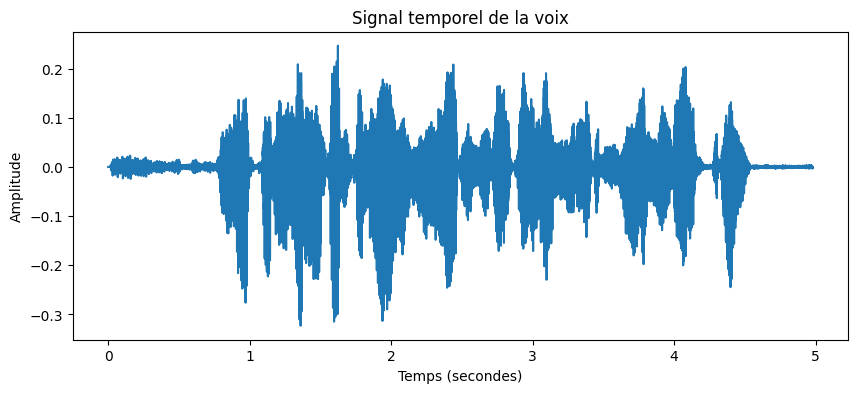

In [3]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

signal, sr = librosa.load("voice_recording.wav", sr=None)

time = np.linspace(0, len(signal)/sr, len(signal))

plt.figure(figsize=(10,4))
plt.plot(time, signal)
plt.title("Signal temporel de la voix")
plt.xlabel("Temps (secondes)")
plt.ylabel("Amplitude")
plt.show()

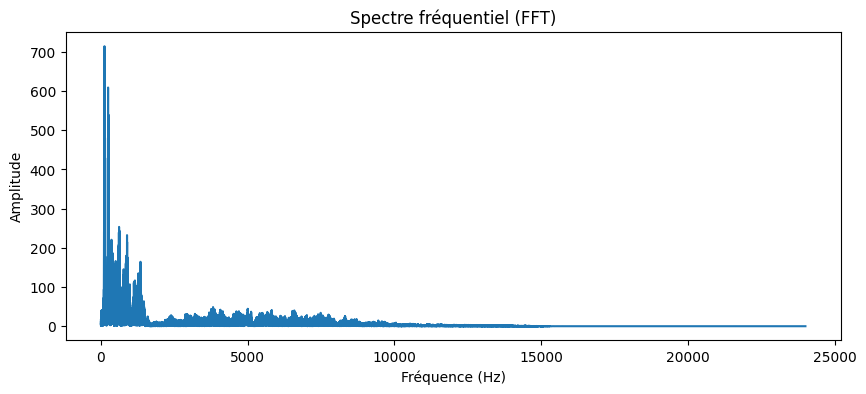

In [4]:
fft = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(fft), 1/sr)

magnitude = np.abs(fft)

plt.figure(figsize=(10,4))
plt.plot(freqs[:len(freqs)//2], magnitude[:len(freqs)//2])
plt.title("Spectre fréquentiel (FFT)")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.show()

In [5]:
peak_index = np.argmax(magnitude[:len(magnitude)//2])
pitch = freqs[peak_index]

print("Fréquence fondamentale approximative :", pitch, "Hz")

Fréquence fondamentale approximative : 122.89156626506026 Hz


Après analyse des spectres, nous avons observé que chaque membre possède une fréquence fondamentale différente. La personne A possède la voix la plus grave avec une fréquence fondamentale de 110 Hz. La personne B possède un spectre plus riche en harmoniques hautes fréquences. La superposition des spectres montre que plusieurs composantes fréquentielles se chevauchent, ce qui rend la séparation des voix difficile lorsqu'elles sont mélangées.